In [ ]:
# Install tensorflow version 2.17.0.
!pip install tensorflow==2.17.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.1

In [ ]:
# Install scikeras with its upgrade
!pip install --upgrade scikeras scikit-learn==1.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 47.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.


In [ ]:
# Istall keras version 3.2.0
!pip install keras==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.17.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.17.0 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.17.0 which is incompatible.


### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Activation
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasRegressor


In [ ]:
# Mount to Google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Read in the data set CaliforniaHousingWHeader into a Panda's DataFrame. Then convert the DataFrame into a Numpy array dataset.

In [ ]:
# Read in the data and assign the values to columns accordingly
dataframe = pd.read_csv("/content/drive/MyDrive/Dataset/CaliforniaHousingWHeader.csv")
dataset = dataframe.values
#dataframe = pd.read_csv('train.csv')

# Data Exploration and preprocessing

In [ ]:
# view dataframe
dataframe.head(5)

,longtitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-122.23,37.88,41,880,129,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200


In [ ]:
# Show the Numpy array dataset
dataset

array([[-1.2223e+02,  3.7880e+01,  4.1000e+01, ...,  1.2600e+02,
         8.3252e+00,  4.5260e+05],
       [-1.2222e+02,  3.7860e+01,  2.1000e+01, ...,  1.1380e+03,
         8.3014e+00,  3.5850e+05],
       [-1.2224e+02,  3.7850e+01,  5.2000e+01, ...,  1.7700e+02,
         7.2574e+00,  3.5210e+05],
       ...,
       [-1.2122e+02,  3.9430e+01,  1.7000e+01, ...,  4.3300e+02,
         1.7000e+00,  9.2300e+04],
       [-1.2132e+02,  3.9430e+01,  1.8000e+01, ...,  3.4900e+02,
         1.8672e+00,  8.4700e+04],
       [-1.2124e+02,  3.9370e+01,  1.6000e+01, ...,  5.3000e+02,
         2.3886e+00,  8.9400e+04]])

In [ ]:
# duplicating and saving the dataframe
df = dataframe.copy()

In [ ]:
# Show (describe) the statistics of the DataFrame df
df.describe()

,longtitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.898014,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.247906,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,295.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# Access the columns with the correct name, if it exists
df["medianHouseValue"].value_counts

<bound method IndexOpsMixin.value_counts of 0        452600
1        358500
2        352100
3        341300
4        342200
          ...  
20635     78100
20636     77100
20637     92300
20638     84700
20639     89400
Name: medianHouseValue, Length: 20640, dtype: int64>

**Check for missing data and type of data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   longtitude        20640 non-null  float64
 1   latitude          20640 non-null  float64
 2   housingMedianAge  20640 non-null  int64  
 3   totalRooms        20640 non-null  int64  
 4   totalBedrooms     20640 non-null  int64  
 5   population        20640 non-null  int64  
 6   households        20640 non-null  int64  
 7   medianIncome      20640 non-null  float64
 8   medianHouseValue  20640 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.4 MB


**Check if there are any null values**

In [ ]:
# recheck if there any null values
df.isnull().sum()

,0
longtitude,0
latitude,0
housingMedianAge,0
totalRooms,0
totalBedrooms,0
population,0
households,0
medianIncome,0
medianHouseValue,0


**As we can see, there are no null values**

### Visualize the data with Scikit-Learn

In [ ]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sb

**Correlation heat map**

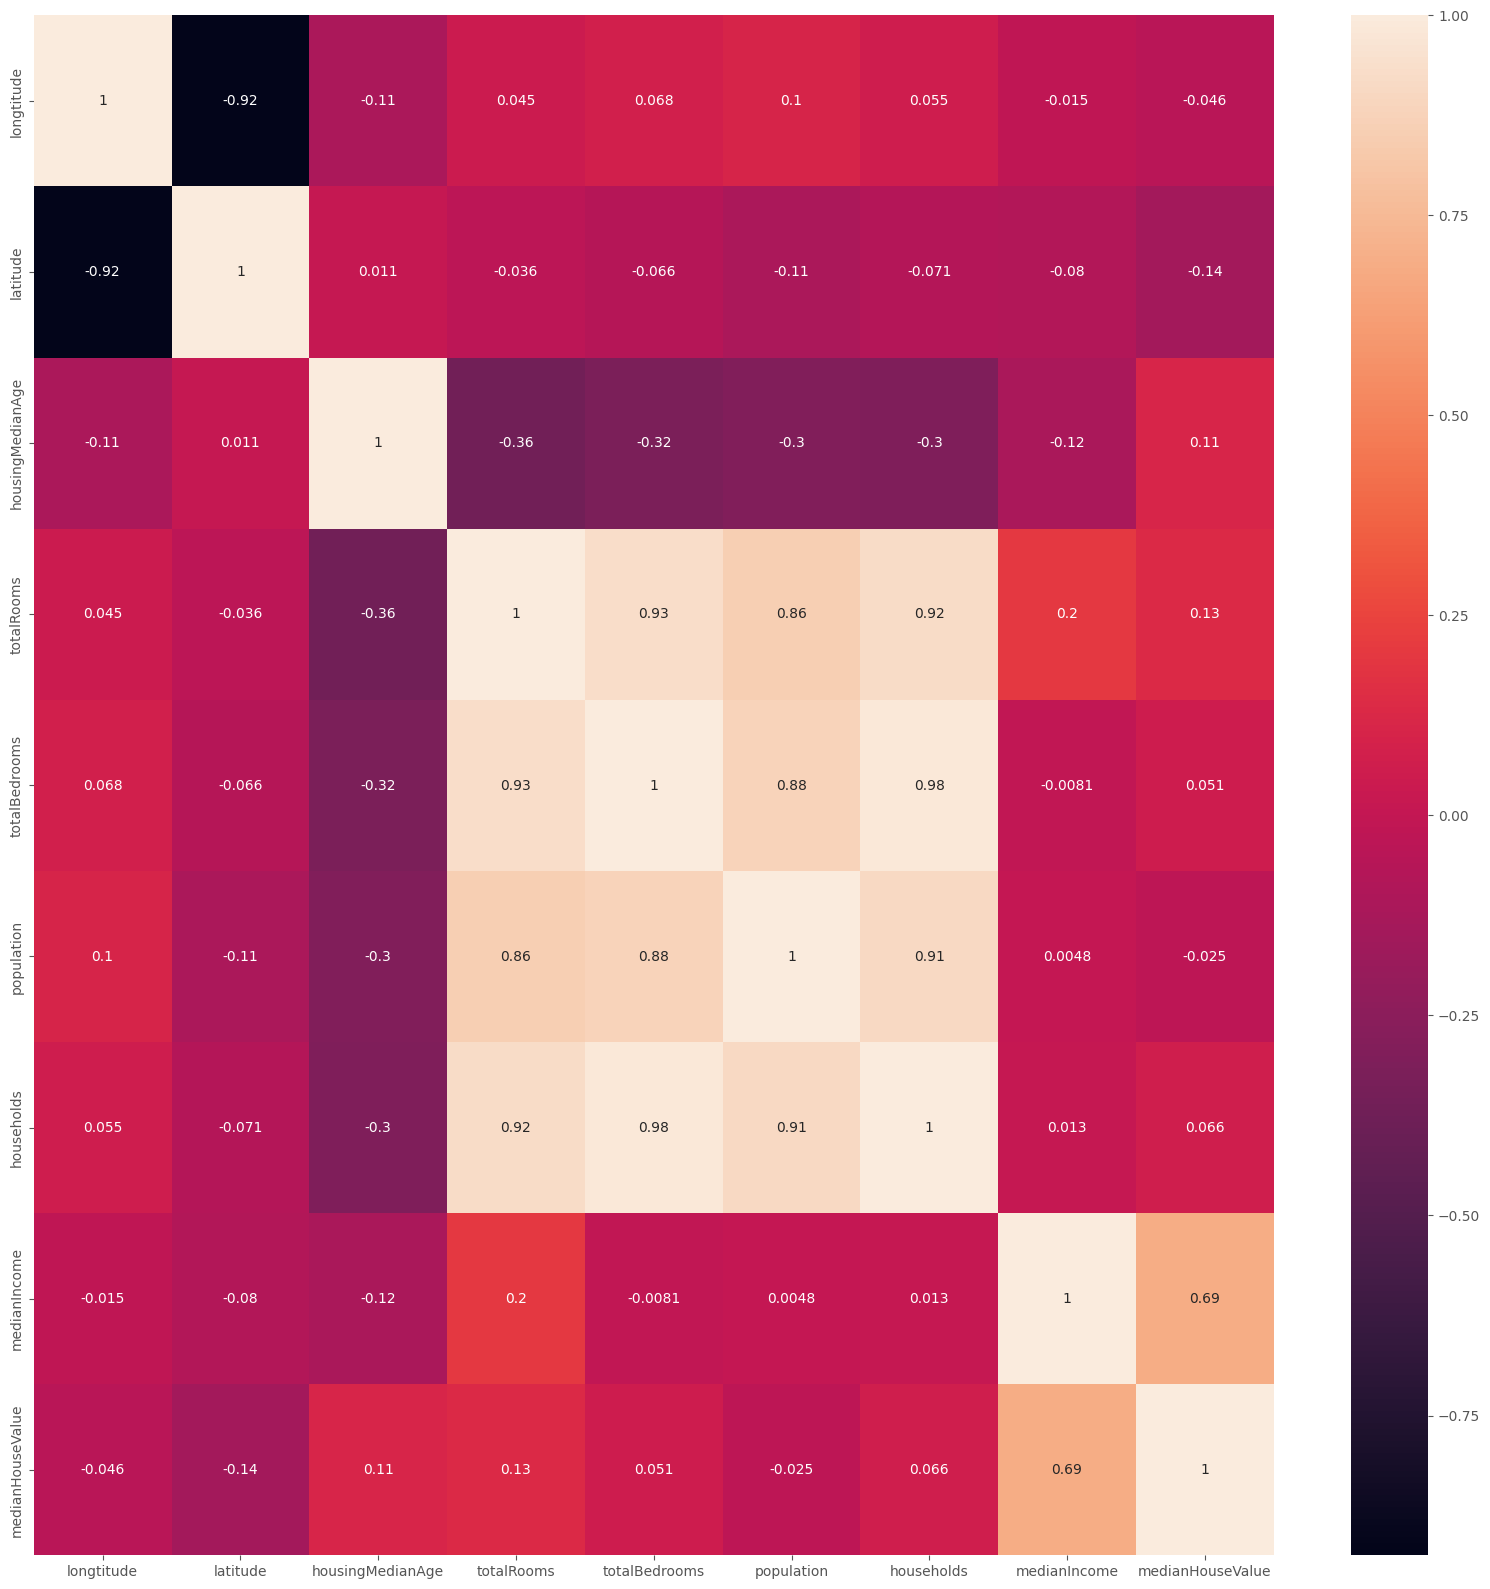

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize = (20, 20
                      ))
sb.heatmap(df.corr(), annot= True)
plt.show()

**Top 10 Highest Positive Correlation**

In [ ]:
correlations = df.corr()['medianHouseValue'].sort_values(ascending=False)
print('Top 10 Positive Correlation\n', correlations.head(11))

Top 10 Positive Correlation
 medianHouseValue    1.000000
medianIncome        0.688075
totalRooms          0.134153
housingMedianAge    0.105623
households          0.065843
totalBedrooms       0.050594
population         -0.024650
longtitude         -0.045967
latitude           -0.144160
Name: medianHouseValue, dtype: float64


**Top 10 Highest Negative Correlation**

In [ ]:
correlations = df.corr()['medianHouseValue'].sort_values(ascending=True)
print('Top 10 Negative Correlation\n', correlations.head(11))

Top 10 Negative Correlation
 latitude           -0.144160
longtitude         -0.045967
population         -0.024650
totalBedrooms       0.050594
households          0.065843
housingMedianAge    0.105623
totalRooms          0.134153
medianIncome        0.688075
medianHouseValue    1.000000
Name: medianHouseValue, dtype: float64


**Most of the features have relatively high correlation with critical temp, therefore creating models to predict this data set should not be a problem**

**Visualize the range of Critical Temperature**

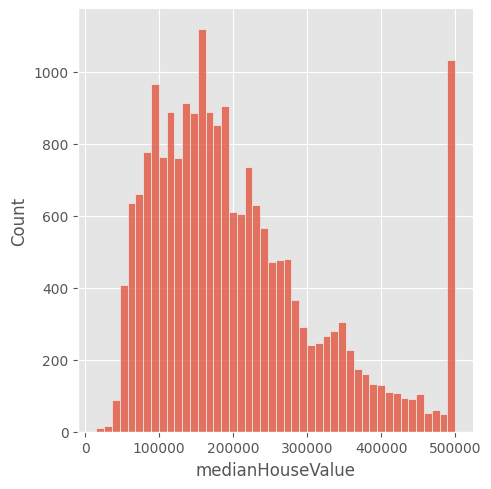

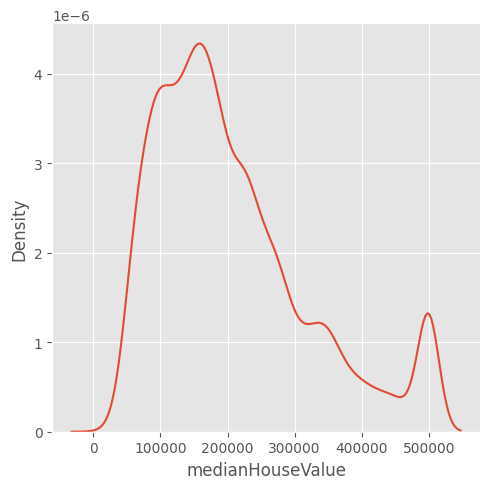

In [ ]:
sb.displot(data = df, x = 'medianHouseValue')
sb.displot(data = df, x = 'medianHouseValue', kind = 'kde')

**The values of critical temperature are left-skewed**

### Train Test Split

**Use 2/3 data for training and 1/3 for test** Split the dataset using stratified process.

In [ ]:
# training and splitting the dataset to process
X = df.drop(columns=['medianHouseValue'])
y = df['medianHouseValue']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=42)

### Normalize the data with scaler

In [ ]:
# scaling the training set between the range 0 and 1
columns = ["longtitude","latitude","housingMedianAge","totalRooms", \
                    "totalBedrooms","population","households","medianIncome"]
scaler = MinMaxScaler()
scaler.fit(X_train[columns])
X_train[columns] = scaler.transform(X_train[columns])

X_train

,longtitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
5088,0.604582,0.152128,0.352941,0.027004,0.048417,0.020264,0.045387,0.033172
17096,0.211155,0.522340,0.627451,0.080950,0.071850,0.028364,0.070054,0.256776
5617,0.606574,0.131915,0.803922,0.035556,0.040813,0.029177,0.039467,0.210266
20060,0.506972,0.353191,0.450980,0.048674,0.060366,0.047171,0.061010,0.079102
895,0.238048,0.530851,0.254902,0.156444,0.187151,0.076656,0.182042,0.240755
...,...,...,...,...,...,...,...,...
11284,0.636454,0.130851,0.666667,0.040705,0.031037,0.018358,0.035520,0.404829
11964,0.689243,0.156383,0.627451,0.094467,0.088299,0.049048,0.073672,0.175867
5390,0.594622,0.157447,0.686275,0.064337,0.088144,0.049133,0.086499,0.167894
860,0.238048,0.535106,0.274510,0.109517,0.092489,0.049721,0.091761,0.359947


In [ ]:
# scaling the test set between the range 0 and 1
X_test[columns] = scaler.transform(X_test[columns])
X_test

,longtitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
20046,0.531873,0.373404,0.470588,0.046069,0.056797,0.038930,0.058872,0.081468
3024,0.487052,0.275532,0.568627,0.090146,0.108007,0.043779,0.095872,0.140095
15663,0.190239,0.558511,1.000000,0.117333,0.177064,0.036632,0.158198,0.205528
20484,0.560757,0.184043,0.313725,0.093456,0.078212,0.047703,0.081237,0.361216
9814,0.241036,0.432979,0.647059,0.072000,0.068125,0.029709,0.070219,0.222418
...,...,...,...,...,...,...,...,...
15316,0.696215,0.069149,0.352941,0.058973,0.086282,0.033269,0.079263,0.057034
14772,0.725100,0.002128,0.254902,0.046743,0.055245,0.034222,0.059530,0.154219
12870,0.293825,0.655319,0.274510,0.143387,0.117474,0.073517,0.119717,0.230038
13476,0.693227,0.163830,0.176471,0.175755,0.146493,0.098798,0.153100,0.268679


In [ ]:
# standardizing the values
scaler.fit(y_train.values.reshape(-1,1))
y_train = scaler.transform(y_train.values.reshape(-1,1))
y_train = y_train.reshape(-1)
y_train = pd.Series(y_train)
y_train

,0
0,0.219383
1,0.718968
2,0.392990
3,0.067218
4,0.455670
...,...
13823,0.441650
13824,0.170723
13825,0.427011
13826,0.553608


In [ ]:
# standardizing the values
y_test = scaler.transform(y_test.values.reshape(-1,1))
y_test = y_test.reshape(-1)
y_test = pd.Series(y_test)
y_test

,0
0,0.067424
1,0.063507
2,1.000000
3,0.419794
4,0.542268
...,...
6807,0.311547
6808,0.162063
6809,0.189692
6810,0.238558


### Artificial Neural Network

**Artificial Neural Network (ANN) is a network of groups of small processing units that are modeled based on the behavior of human neural networks. A multilayer perceptron (MLP) is a fully connected class of feedforward artificial neural network.**

### Building the ANN model

**In this task, we will use keras to build our ANN model, by creating an MLP using Sequential API**

In [ ]:
# Creating an MLP using the Sequential API
# 2 hidden layers and MSE as loss function
# Default to 2 hidden layers, 15 neurons per layer,
# with an input shape of 8 (8 features)

# Define the model building function for KerasRegressor
def build_model(n_hidden=2, n_neurons=15, reg_param=2e-4, input_shape=(8,)):
    model = tf.keras.models.Sequential()
    # This adds an input layer where each input sample is shaped according to
    # input_shape
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))

    # This loop adds n_hidden hidden layers to the model, each with n_neurons
    # neurons and a ReLU activation function.
    for layer in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu",
                       kernel_regularizer=tf.keras.regularizers.l2(reg_param)))

    # This adds an output layer to the model with a single neuron.
    # This layer will output a single value, which is the predicted output of
    # the model.
    model.add(tf.keras.layers.Dense(1))  # Output layer for regression

    # Compile with loss function and the optimizer
    # Train the model using Adaptive Moment Estimation 'adam' optimiser
    # Use Mean Squared Error (mse) to calculate loss
    model.compile(loss='mse', optimizer='adam')

    # return the model
    return model

# Pass the parameters to the KerasRegressor constructor
keras_reg = KerasRegressor(build_fn=build_model,
                           n_hidden=2,
                           n_neurons=8,
                           verbose=0,
                           reg_param=0.0002)

param_distribs = {
   'n_hidden': [1, 2], # must have at least two hidden layers as specified in the assignment instructions
   'n_neurons': [8, 16],
   'reg_param': [2e-4, 2e-3]
}

search_cv = GridSearchCV(keras_reg,
                         param_distribs,
                         cv=3,
                         error_score = 'raise',
                         scoring='neg_mean_squared_error',
                         return_train_score=True,
                         verbose=3)
n_records = 32
search_cv.fit(X_train, y_train, epochs=10, batch_size=n_records)

# best_model = search_cv.best_estimator_
best_model = search_cv.best_estimator_.model_
best_model.summary()

# Use the predict method to get predictions from the best model
predictions = best_model.predict(X_test)

best_model.summary()

best_params = search_cv.best_params_
best_score = abs(search_cv.best_score_)
print(best_score)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


[CV 1/3] END n_hidden=1, n_neurons=8, reg_param=0.0002;, score=(train=-0.021, test=-0.020) total time=   5.2s


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


[CV 2/3] END n_hidden=1, n_neurons=8, reg_param=0.0002;, score=(train=-0.021, test=-0.020) total time=   5.9s


...

 Total params: 1,301 (5.09 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 868 (3.39 KB)

0.018337618605551


In [ ]:
keras_reg = KerasRegressor(build_fn=build_model,
                           n_hidden=1,
                           n_neurons=8,
                           verbose=0,
                           reg_param=0.0002)

In [ ]:
keras_reg

KerasRegressor(
	model=None
	build_fn=<function build_model at 0x7bbe1c783f60>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	n_hidden=1
	n_neurons=8
	reg_param=0.0002
)

In [ ]:
n_records = 32
import numpy as np
x = np.array(X_train[:-3000])
y = np.array(y_train[:-3000])
x_val = np.array(X_train[-3000:])
y_val = np.array(y_train[-3000:])

model_reg = build_model()
model_reg.fit(x, y,
              validation_data=(x_val,y_val),
              #epochs=40,
              epochs=10,
              batch_size=n_records)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0742 - val_loss: 0.0286
Epoch 2/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0266 - val_loss: 0.0264
Epoch 3/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0255 - val_loss: 0.0254
Epoch 4/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0242 - val_loss: 0.0236
Epoch 5/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0231 - val_loss: 0.0229
Epoch 6/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0217 - val_loss: 0.0226
Epoch 7/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0208 - val_loss: 0.0219
Epoch 8/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0207 - val_loss: 0.0212
Epoch 9/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0195 - val_loss: 0.0213
Epoch 10/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0199 - val_loss: 0.0207


### Evaluating the model

**Evaluate for training set**

In [ ]:
# evaluating and predicting the model
# Convert X_train and y_train to Numpy arrays with fixed dimensions
X_train = np.array(X_train)
y_train = np.array(y_train)

model_reg.evaluate(X_train,y_train)
model_reg.predict(X_train)

433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.0196
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.23030081],
       [0.51403725],
       [0.39443856],
       ...,
       [0.35660228],
       [0.5384143 ],
       [0.63308364]], dtype=float32)

**Evaluating for testing set**

In [ ]:
# evaluating and predicting the model
# Convert X_test and y_test to Numpy arrays with fixed dimensions
X_test = np.array(X_test)
y_test = np.array(y_test)

model_reg.evaluate(X_test,y_test)
model_reg.predict(X_test)

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0198
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step


array([[0.11982322],
       [0.33635017],
       [0.7477073 ],
       ...,
       [0.22232205],
       [0.2681194 ],
       [0.44434866]], dtype=float32)

### Fine tuning the model

**First, we build a grid of hyperparameters to try out which is the best set**

In [ ]:
# Fine-Tuning Neural Network Hyperparameters for the model
param_distribs = {
   'n_hidden': [1, 2], # must have at least two hidden layers as specified in the assignment instructions
   'n_neurons': [8, 16],
   'reg_param': [2e-4, 2e-3]
}


In [ ]:
import numpy as np
x = np.array(X_train[:-3000])
y = np.array(y_train[:-3000])
x_val = np.array(X_train[-3000:])
y_val = np.array(y_train[-3000:])

param_distribs = {'n_hidden':[1,2],
                  'n_neurons':[8,16],
                  'reg_param':[2e-4,2e-3]}

# Fit the KerasRegressor to build the underlying Keras model
# keras_reg.fit(x, y)
model_reg.fit(x, y,
              validation_data=(x_val,y_val),
              #epochs=40,
              epochs=10,
              batch_size=n_records)

search_cv = GridSearchCV(#model_reg,
                         keras_reg,
                         param_distribs,
                         cv=3,
                         error_score = 'raise',
                         #scoring='raise',
                         scoring='neg_mean_squared_error',
                         return_train_score=True,
                         verbose=3)

print("Parameters used in keras_reg:", keras_reg.get_params())

search_cv.fit(X_train, y_train)
best_params = search_cv.best_params_
best_score = abs(search_cv.best_score_)
print(best_score)

# Get the best model summary
best_model = search_cv.best_estimator_.model_
best_model.summary()

Epoch 1/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0184 - val_loss: 0.0197
Epoch 2/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0178 - val_loss: 0.0214
Epoch 3/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0184 - val_loss: 0.0194
Epoch 4/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - val_loss: 0.0199
Epoch 5/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0180 - val_loss: 0.0195
Epoch 6/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0184 - val_loss: 0.0195
Epoch 7/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0181 - val_loss: 0.0194
Epoch 8/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0173 - val_loss: 0.0205
Epoch 9/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0174 - val_loss: 0.0191
Epoch 10/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0180 - val_loss: 0.0191
Parameters used in keras_reg: {'model': None, 'build_fn': <function build_model at 0x7bbe1c783f60>, 'warm_start': False, 'random_state': No

/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


[CV 1/3] END n_hidden=1, n_neurons=8, reg_param=0.0002;, score=(train=-0.052, test=-0.050) total time=   1.6s


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


[CV 2/3] END n_hidden=1, n_neurons=8, reg_param=0.0002;, score=(train=-0.036, test=-0.036) total time=   1.9s


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_378 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_379 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_380 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,301 (5.09 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 868 (3.39 KB)

In [ ]:
search_cv.best_params_

{'n_hidden': 2, 'n_neurons': 16, 'reg_param': 0.0002}

### Evaluating the model after tuning

In [ ]:
#getting the best model summary
best_params = search_cv.best_params_
best_model = build_model(n_hidden=best_params['n_hidden'],
                         n_neurons=best_params['n_neurons'],
                         reg_param=best_params['reg_param'])
best_model.summary()

In [ ]:
# evaluating the model and making predictions after hypertuning
best_params = search_cv.best_params_
best_model = build_model(n_hidden=best_params['n_hidden'],
                         n_neurons=best_params['n_neurons'],
                         reg_param=best_params['reg_param'])
best_model.evaluate(np.array(X_train),np.array(y_train))
best_model.predict(X_train)

In [ ]:
# evaluating the model and making predictions after hypertuning
best_params = search_cv.best_params_
best_model = build_model(n_hidden=best_params['n_hidden'],
                         n_neurons=best_params['n_neurons'],
                         reg_param=best_params['reg_param'])
best_model.evaluate(np.array(X_test),np.array(y_test))
best_model.predict(X_test)